# Install packages

In [1]:
!pip install swig mediapy
!pip install ax-platform==0.5.0
!pip install mujoco==2.3.4
!pip install gymnasium==0.29.1 gymnasium[box2d] gymnasium[mujoco]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

# Imports and Functions

In [2]:
import gymnasium as gym
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import scipy
import torch
import botorch
import gpytorch
import mediapy as media
import ax
from ax.service.ax_client import AxClient
from ax.utils.notebook.plotting import render
# Change to glfw when on Mac. This might fuck up the lighting.
%env MUJOCO_GL=egl

[WARNING 05-26 07:18:26] ax.service.utils.with_db_settings_base: Ax currently requires a sqlalchemy version below 2.0. This will be addressed in a future release. Disabling SQL storage in Ax for now, if you would like to use SQL storage please install Ax with mysql extras via `pip install ax-platform[mysql]`.


env: MUJOCO_GL=egl


In [3]:
def render_episode(policy, env_name, env_options={}):
    env = gym.make(env_name,render_mode='rgb_array',**env_options)
    frames = []
    score = 0
    state = env.reset()[0]
    terminated = truncated = False
    while not terminated and not truncated:
        frame = env.render()
        frames.append(frame)
        action = policy(state)
        state, reward, terminated, truncated, _ = env.step(action)
        score += reward
    env.close()
    print(f"Finished episode. Cummulative Return: {score}")
    media.show_video(frames, fps=30, loop=True)

# Bayesian Optimizations
Bayesian optimization is a powerful technique used for optimizing black-box functions that are expensive to evaluate. It combines the principles of Bayesian inference and optimization to efficiently search for the optimal set of parameters or inputs. The key idea behind Bayesian optimization is to build a probabilistic model, typically a Gaussian process, that captures the relationship between the inputs and the corresponding function values. This model is then updated iteratively as new observations are made, allowing for the exploration of promising regions of the parameter space while exploiting areas with high expected improvement. By intelligently selecting the next set of inputs to evaluate based on the model's predictions and uncertainty estimates, Bayesian optimization can converge to the optimal solution with a minimal number of function evaluations. This makes it particularly useful in scenarios where the evaluation of the objective function is time-consuming or costly, such as hyperparameter tuning in machine learning or optimizing complex simulations.

## Gaussian processes
Gaussian processes are powerful statistical models that are commonly used as surrogate models in Bayesian optimization. A Gaussian process defines a distribution over functions, allowing us to model the uncertainty associated with the true underlying function we are trying to optimize.

In the context of Bayesian optimization, a Gaussian process is used to approximate the objective function. It provides a flexible and tractable way to model the relationship between input variables and their corresponding outputs. By fitting the Gaussian process to a set of observed data points, we can estimate the mean and covariance of the underlying function, which in turn allows us to make predictions at new, unseen points.

The use of Gaussian processes as surrogate models in Bayesian optimization offers several advantages. Firstly, they naturally handle noisy observations, which is often the case in real-world optimization problems. Secondly, they provide a measure of uncertainty, allowing us to balance exploration and exploitation in the optimization process. This means that we can choose to sample points in regions of high uncertainty to gather more information about the function, or in regions of high expected improvement to exploit promising areas. Lastly, Gaussian processes are well-suited for high-dimensional optimization problems, making them a versatile tool for a wide range of applications.

Overall, Gaussian processes serve as a valuable surrogate model in Bayesian optimization, enabling efficient and effective exploration of the parameter space while considering uncertainty and noisy measurements.

In [4]:
# Define a Gaussian Process class
class GaussianProcess:
    def __init__(self, kernel, noise=1e-3):
        self.kernel = kernel
        self.noise = noise
        self.X = None
        self.y = None
        self.K = None
        self.K_inv = None

    def fit(self, X, y):
        self.X = X
        self.y = y
        self.K = self.kernel(X, X) + self.noise
        self.K_inv = np.linalg.inv(self.K) # Note that matrix inversion is expensive

    def predict(self, X_pred):
        K_star = self.kernel(self.X, X_pred)
        mu = K_star.T @ self.K_inv @ self.y
        cov = self.kernel(X_pred, X_pred) - K_star.T @ self.K_inv @ K_star
        diag = np.diagonal(cov).copy()
        diag[diag < 0.] = 0.
        sigma = np.sqrt(diag)
        return mu, sigma

### Acquisition functions
Acquisition functions play a crucial role in Bayesian optimization. These functions guide the search for the optimal set of parameters or inputs by balancing exploration and exploitation. The goal is to efficiently explore the parameter space while considering uncertainty and noisy measurements. Different acquisition functions, such as Expected Improvement, Upper Confidence Bound, and Entropy, offer different strategies for selecting the next set of inputs to evaluate. They leverage the probabilistic model, typically a Gaussian process, to estimate the expected improvement, uncertainty, or information gain at each point. By intelligently choosing the inputs that maximize these acquisition functions, Bayesian optimization can converge to the optimal solution with minimal function evaluations, making it particularly useful in scenarios where function evaluation is time-consuming or costly.

In [5]:
# Some acquisition functions
# Point where the expectation of improvement over the current best observation is the highest.
def expected_improvement(mu, sigma, tau, xi=0.01):
    z = (mu - tau - xi) / sigma
    return (mu - tau - xi) * scipy.stats.norm.cdf(z) + sigma * scipy.stats.norm.pdf(z)

# Point that reduces the uncertainty about the function in the search space most.
def entropy(mu, sigma, tau):
    return 0.5 * np.log(2 * np.pi * np.e * sigma**2)

# Point that maximizes the upper confidence bound of the function.
def upper_confidence_bound(mu, sigma, tau, kappa=2.576):
    return mu + kappa * sigma


In [6]:
# Define the Bayesian optimization class
class BayesOpt:
    def __init__(self, x_init, y_init, bounds):
        self.bounds = bounds
        self.x_samples = x_init
        self.y_samples = y_init

        # Create a Gaussian Process surrogate model
        self.surrogate_model = GaussianProcess(kernel=lambda x1, x2: np.exp(-.5 * np.subtract.outer(x1, x2)**2))
        self.surrogate_model.fit(self.x_samples, self.y_samples)

    def update_model(self, x, y):
        if not x in self.x_samples:
            self.x_samples = np.append(self.x_samples, x)
            self.y_samples = np.append(self.y_samples, y)
            self.surrogate_model.fit(self.x_samples, self.y_samples)
        else:
            print(f"Warning: x = {x} already in samples. Skipping...")

    def get_candidate(self, acquisition_function, num_candidates=1000):
        x_canditates = np.linspace(self.bounds[0], self.bounds[1], num_candidates)
        mu,sigma = self.surrogate_model.predict(x_canditates)
        aqf_values = acquisition_function(mu, sigma, np.max(self.y_samples))
        best_index = np.argmax(aqf_values)
        return x_canditates[best_index]

    def get_best_values(self):
        best_index = np.argmax(self.y_samples)
        return self.x_samples[best_index], self.y_samples[best_index]

    def plot_2d(self, next_candidate = None,  true_func = None, num_x = 1001):
        fig, ax = plt.gcf(), plt.gca()
        fig.set_size_inches(12, 6)
        xPred = np.linspace(self.bounds[0], self.bounds[1], num_x)
        ypred,stds = self.surrogate_model.predict(xPred)
        ax.clear()
        ax.plot(self.x_samples,self.y_samples,'or',label="training data")
        ax.plot(xPred,ypred,'k--',label="predictions")
        fillx = np.r_[xPred, xPred[::-1]]
        filly = np.r_[ypred+2*stds, ypred[::-1]-2*stds[::-1]]
        ax.fill(fillx, filly, facecolor='gray', edgecolor='white', alpha=0.3, label='95% confidence interval')
        if next_candidate:
            ax.axvline(next_candidate,label="next candidate")
        if true_func:
            ax.plot(xPred, true_func(xPred), "g-", label="true function")
        ax.legend(numpoints=1)
        ax.set_xlabel('x')
        ax.set_ylabel('f(x)')
        fig.show()

In [7]:
# this is the true function we want to optimize
true_function = lambda x: 0.5* (np.sin(2.5*x) + np.sin(0.5*x) - 0.1*(x+2)**2 + 0.5*x)
# this is the acquisition function we want to use
aq_func = entropy
# create the bayesian optimization object
bayes_opt = BayesOpt(np.array([0]), np.array([true_function(0)]), [-5, 5])
# get the next candidate
x_next = bayes_opt.get_candidate(aq_func)

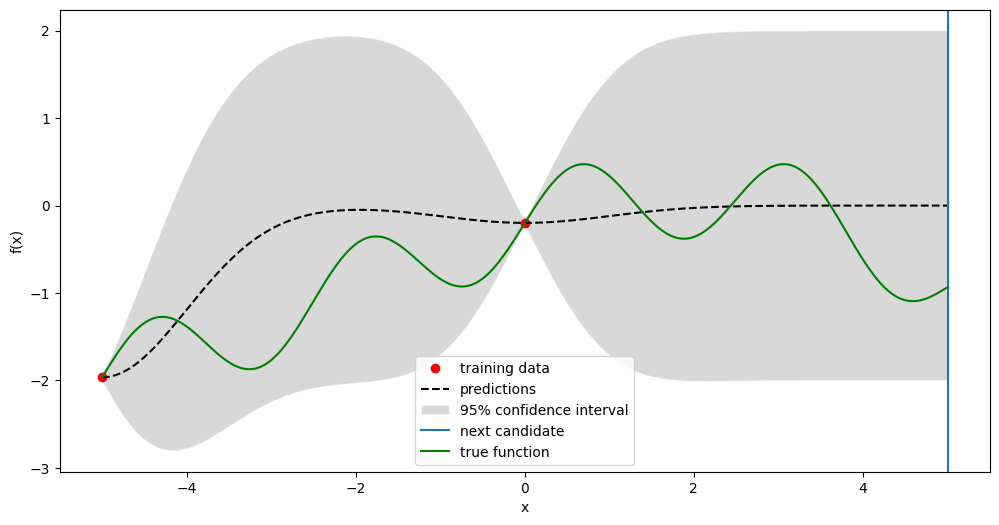

In [8]:
# You can execute this cell multiple times to get more and more samples
for i in range(1):
    y_next = true_function(x_next)
    bayes_opt.update_model(x_next, y_next)
    x_next = bayes_opt.get_candidate(aq_func)
    bayes_opt.plot_2d(next_candidate=x_next, true_func=true_function)

### Tasks
1. Execute the last cell until a good fit to the function is found.
2. Play around with different kernels (e.g., change the kernel size) of the Gaussian process. What changes?
3. Play around with different aqcuisition functions. What are their differences?
4. Change the frequency of the true function. What do you observe?

# BayesOpt with Ax
Ax is a powerful Python library that enables efficient and effective Bayesian optimization. With Ax, you can easily define your optimization problem by specifying the search space, objective function, and constraints. Ax provides a wide range of acquisition functions, such as Expected Improvement and Upper Confidence Bound, which allow you to balance exploration and exploitation during the optimization process. Additionally, Ax supports parallel and sequential optimization strategies, enabling you to efficiently explore the parameter space and converge to the optimal solution with minimal function evaluations. With its intuitive API and extensive functionality, Ax is a valuable tool for automating and optimizing complex tasks, such as hyperparameter tuning in machine learning or optimizing simulations.

In [9]:
botorch_model_kwargs = {
    'surrogate': ax.models.torch.botorch_modular.surrogate.Surrogate(
        botorch_model_class=botorch.models.SingleTaskGP,
        # MLL class with which to optimize model parameters of GP (e.g., the kernel)
        mll_class=gpytorch.mlls.ExactMarginalLogLikelihood
    ),
    # The acquisition function
    'botorch_acqf_class': botorch.acquisition.LogExpectedImprovement,
    'acquisition_options':{},
    'acquisition_class':None,
}

# We instantiate a Generation stratey with multiple steps
gs_steps=[
        # Quasi-random initialization step
        ax.modelbridge.generation_strategy.GenerationStep(
            model=ax.modelbridge.registry.Models.SOBOL,
            num_trials=5,  # How many trials should be produced from this generation step
        ),
        # Bayesian optimization step using the custom acquisition function
        ax.modelbridge.generation_strategy.GenerationStep(
            model=ax.modelbridge.registry.Models.BOTORCH_MODULAR,
            num_trials=-1,  # No limitation on how many trials should be produced from this step
            # For `BOTORCH_MODULAR`, we pass in kwargs to specify what surrogate or acquisition function to use.
            model_kwargs=botorch_model_kwargs,
        ),
    ]
gs = ax.modelbridge.generation_strategy.GenerationStrategy(steps=gs_steps)

<ipython-input-9-79e761f0027a>:2: DeprecationWarning:

botorch_model_class is deprecated and will be removed in a future version. Please specify botorch_model_class via `surrogate_spec.model_configs`.



In [10]:
# Define the quadratic function
function = lambda data: 0.5* (np.sin(2.5*data['x']) + np.sin(0.5*data['x']) - 0.1*(data['x']+2)**2 + 0.5*data['x'])

# Define the search space
search_space = [{"name": "x", "type": "range", "bounds": [-5., 5.]}]

# Create the AxClient with the GP model
ax_client = ax.service.ax_client.AxClient(generation_strategy=gs)

# Define the Experiment
ax_client.create_experiment(
    name="test",
    parameters=search_space,
    objectives={"func": ax.service.ax_client.ObjectiveProperties(minimize=False)},
    overwrite_existing_experiment=True,
)

[INFO 05-26 07:18:27] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 05-26 07:18:27] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter x. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-26 07:18:27] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='x', parameter_type=FLOAT, range=[-5.0, 5.0])], parameter_constraints=[]).


In [11]:
# Run the optimization
for i in range(30):
    parameters, trial_index = ax_client.get_next_trial()
    # Local evaluation here can be replaced with deployment to external system.
    ax_client.complete_trial(trial_index=trial_index, raw_data=function(parameters))


/usr/local/lib/python3.11/dist-packages/ax/modelbridge/cross_validation.py:439: UserWarning:

Encountered exception in computing model fit quality: RandomModelBridge does not support prediction.

[INFO 05-26 07:18:27] ax.service.ax_client: Generated new trial 0 with parameters {'x': 2.395959} using model Sobol.
[INFO 05-26 07:18:27] ax.service.ax_client: Completed trial 0 with data: {'func': (np.float64(-0.046131), None)}.
/usr/local/lib/python3.11/dist-packages/ax/modelbridge/cross_validation.py:439: UserWarning:

Encountered exception in computing model fit quality: RandomModelBridge does not support prediction.

[INFO 05-26 07:18:27] ax.service.ax_client: Generated new trial 1 with parameters {'x': -3.804985} using model Sobol.
[INFO 05-26 07:18:27] ax.service.ax_client: Completed trial 1 with data: {'func': (np.float64(-1.543105), None)}.
/usr/local/lib/python3.11/dist-packages/ax/modelbridge/cross_validation.py:439: UserWarning:

Encountered exception in computing model fit qualit

In [12]:
from ax.plot.slice import plot_slice
model = ax_client.generation_strategy.model
render(plot_slice(model,"x","func"))

### Tasks:
1. What happens if we increase the frequency of the periodic functions?
2. What happens if we introduce a discontinuity close to the maximum? Can you add a best point that is not found by the algorithm?

# High-Dimensional Bayesian optimization - Controller for Cartpole
Bayesian optimization is easily extended to higher dimensional problems. The search space in high-dimensional problems becomes exponentially larger which is why we need to carefully select candidate parameterizations.

Here we use it to find a good set of controller parameters for the cartpole example from our introdiction to control exercise.


In [13]:
# State-feedback controller
def controller(state, gain):
    return (- (gain['p_x'] * state[0] + gain['p_theta'] * state[1] + gain['d_x'] * state[2] + gain['d_theta'] * state[3]),)

In [14]:
# This function evaluates the the controller defined by the gain. Note that evaluating this function is relatively expensive.
def evaluate_pi(gain, env_name = "InvertedPendulum-v4", env_options={}, eval_runs=5):
	env = gym.make(env_name,**env_options)
	cum_return = 0
	cum_energy = 0
	for run in range(eval_runs):
		state = env.reset()[0] # x, x', theta, theta'
		terminal = truncated = False
		while not terminal and not truncated:
			action = controller(state, gain)
			state, r, terminal, truncated, _ = env.step(action)
			cum_return += r
			cum_energy += np.linalg.norm(action)
	return cum_return/eval_runs, cum_energy/eval_runs


In [15]:
## Solution
# We use Ax to optimize the gains for the controller.
ax_client = ax.service.ax_client.AxClient()
ax_client.create_experiment(
    name='cartpole',
    parameters=[
    {'name': 'p_x',
    'type': 'range',
    'bounds': [-5., 5.],},
    {'name': 'd_x',
    'type': 'range',
    'bounds': [-10., 5.],},
     {'name': 'p_theta',
    'type': 'range',
    'bounds': [-40., 0.],},
    {'name': 'd_theta',
    'type': 'range',
    'bounds': [-10., 5.],},
    ],
    objectives={"cum_return": ax.service.ax_client.ObjectiveProperties(minimize=False)},
    overwrite_existing_experiment=True,
    )

# Optimization loop. We iterate between computing a next set of parameters to evaluate and evaluating them on our function.
for i in range(50):
    parameters, trial_index = ax_client.get_next_trial()
    ax_client.complete_trial(trial_index=trial_index, raw_data=evaluate_pi(parameters)[0])

[INFO 05-26 07:18:55] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 05-26 07:18:55] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter p_x. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-26 07:18:55] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter d_x. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-26 07:18:55] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter p_theta. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-26 07:18:55] ax.s

In [16]:
# Finally, we can get the best set of paramet2aers that ax has found.
best_params, _ = ax_client.get_best_parameters()
print(f"Best parameter set found: {best_params}")

Best parameter set found: {'p_x': -3.4382460239305646, 'd_x': -8.901093661324163, 'p_theta': -25.310556784323076, 'd_theta': -7.545319586929801}


In [17]:
# We can also look at the the estimated function and its uncertainty.
render(ax_client.get_contour_plot(param_x='p_theta', param_y='d_theta')) # you might need to rename the param values to your own specification

[INFO 05-26 07:22:47] ax.service.ax_client: Retrieving contour plot with parameter 'p_theta' on X-axis and 'd_theta' on Y-axis, for metric 'cum_return'. Remaining parameters are affixed to the middle of their range.


In [18]:
# render an episode with the best found parameters
render_episode(lambda s: controller(s, best_params), "InvertedPendulum-v4")

Finished episode. Cummulative Return: 1000.0


This browser does not support the video tag.


### Tasks:
1. Fill in the blanks in the Ax code to optimize the controller parameters.
2. Look at different contour plots of the four controller parameters. You might want to adapt your code using the knowledge you obtain from the plots.
3. Compare the found parameters with the LQR solutions from the 'Intro to Control' exercise.

# Multi-objective optimization with Ax

Multi-objective opimiztaion covers the case where we care about multiple outcomes in our experiment but we do not know before hand a specific weighting of those objectives or a specific constraint on one objective  that will produce the best result. In a multi-objective optimization problem, there typically is no single best solution. Rather, the goal is to identify the set of Pareto optimal solutions such that any improvement in one objective means deteriorating another, i.e., a surface in outcome-space containing points that can't be improved on in every outcome. This shows us the tradeoffs between objectives that we can choose to make. Provided with the Pareto set, decision-makers can select an objective trade-off according to their preferences.

In [19]:
# Load our sample 2-objective problem. This is just an example function.
branin_currin = botorch.test_functions.multi_objective.BraninCurrin(negate=True).to(
    dtype=torch.double,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)

In [20]:
# Create an instance of AxClient
ax_client = AxClient()

# Create a new experiment in AxClient
ax_client.create_experiment(
	name="moo_experiment",
	parameters=[
		{
			"name": f"x{i+1}",
			"type": "range",
			"bounds": [0.0, 1.0],
		}
		for i in range(2)
	],
	objectives={
		# Define multiple objectives with their properties
		# `threshold` arguments are optional
		"a": ax.service.utils.instantiation.ObjectiveProperties(minimize=False, threshold=branin_currin.ref_point[0]),
		"b": ax.service.utils.instantiation.ObjectiveProperties(minimize=False, threshold=branin_currin.ref_point[1]),
	},
	overwrite_existing_experiment=True,
	is_test=True,
)

[INFO 05-26 07:23:11] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 05-26 07:23:11] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter x1. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-26 07:23:11] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter x2. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-26 07:23:11] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='x1', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='x2', parameter_type=FLOAT, range=[0.0, 1.0])], parameter_constraints=[]).
[INFO 05-26 07:23:1

In [21]:
def evaluate(parameters):
    evaluation = branin_currin(
        torch.tensor([parameters.get("x1"), parameters.get("x2")])
    )
    # In our case, standard error is 0, since we are computing a synthetic function.
    # Set standard error to None if the noise level is unknown.
    return {"a": (evaluation[0].item(), 0.0), "b": (evaluation[1].item(), 0.0)}

In [22]:
# Optimization loop.
for i in range(20):
    parameters, trial_index = ax_client.get_next_trial()
    # Local evaluation here can be replaced with deployment to external system.
    ax_client.complete_trial(trial_index=trial_index, raw_data=evaluate(parameters))

/usr/local/lib/python3.11/dist-packages/ax/modelbridge/cross_validation.py:439: UserWarning:

Encountered exception in computing model fit quality: RandomModelBridge does not support prediction.

[INFO 05-26 07:23:11] ax.service.ax_client: Generated new trial 0 with parameters {'x1': 0.771712, 'x2': 0.914723} using model Sobol.
[INFO 05-26 07:23:11] ax.service.ax_client: Completed trial 0 with data: {'a': (-177.966446, 0.0), 'b': (-4.434602, 0.0)}.
/usr/local/lib/python3.11/dist-packages/ax/modelbridge/cross_validation.py:439: UserWarning:

Encountered exception in computing model fit quality: RandomModelBridge does not support prediction.

[INFO 05-26 07:23:11] ax.service.ax_client: Generated new trial 1 with parameters {'x1': 0.091539, 'x2': 0.262334} using model Sobol.
[INFO 05-26 07:23:11] ax.service.ax_client: Completed trial 1 with data: {'a': (-92.456917, 0.0), 'b': (-9.30322, 0.0)}.
/usr/local/lib/python3.11/dist-packages/ax/modelbridge/cross_validation.py:439: UserWarning:

En

In [23]:
# To finalize our search we can then compute the pareto front formed with all our observations.
# All those points (in the pareto front) represent viable solutions each with a different objective compromise.
from ax.plot.pareto_frontier import plot_pareto_frontier
objectives = ax_client.experiment.optimization_config.objective.objectives
frontier = ax.plot.pareto_utils.compute_posterior_pareto_frontier(
    experiment=ax_client.experiment,
    data=ax_client.experiment.fetch_data(),
    primary_objective=objectives[1].metric,
    secondary_objective=objectives[0].metric,
    absolute_metrics=["a", "b"],
    num_points=20,
)
render(plot_pareto_frontier(frontier, CI_level=0.90))

In [24]:
# print values of the pareto front
ax_client.get_pareto_optimal_parameters()

OrderedDict([(19,
              ({'x1': 0.04593738691681535, 'x2': 1.0},
               ({'a': np.float64(-6.310667020188916),
                 'b': np.float64(-2.968698103298112)},
                {'a': {'a': 0.0007687885152415292, 'b': 0.0},
                 'b': {'a': 0.0, 'b': 2.0246438292453542e-06}}))),
             (7,
              ({'x1': 0.03906502332887472, 'x2': 1.0},
               ({'a': np.float64(-7.46699048596243),
                 'b': np.float64(-2.7221017344096796)},
                {'a': {'a': 0.0008119466076756158, 'b': 0.0},
                 'b': {'a': 0.0, 'b': 2.146260334329066e-06}}))),
             (13,
              ({'x1': 0.052174757681802554, 'x2': 0.9797152177015683},
               ({'a': np.float64(-5.532434514902036),
                 'b': np.float64(-3.2326584809475385)},
                {'a': {'a': 0.001972657992614469, 'b': 0.0},
                 'b': {'a': 0.0, 'b': 5.300499011595664e-06}}))),
             (18,
              ({'x1': 0.060206231129

### Tasks:
1. Use multi-objective bayesian optimization to find a good linear controller for the cartpole environment that also optimizes the used energy (which is proportional to the integral over applied forces). You can also add more objectives to optimize or choose another environment.

In [ ]:
## Solution
def evaluate(parameters):
    evaluation = evaluate_pi(parameters)
    return {"cum_return": (evaluation[0], None), "cum_energy": (evaluation[1], None)}

ax_client = ax.service.ax_client.AxClient()
ax_client.create_experiment(
    name='cartpole',
    parameters=[
    {'name': 'p_x',
    'type': 'range',
    'bounds': [-5., 5.],},
    {'name': 'd_x',
    'type': 'range',
    'bounds': [-10., 5.],},
     {'name': 'p_theta',
    'type': 'range',
    'bounds': [-40., 0.],},
    {'name': 'd_theta',
    'type': 'range',
    'bounds': [-10., 5.],},
    ],
    objectives={"cum_return": ax.service.ax_client.ObjectiveProperties(minimize=False, threshold=500.0),
                "cum_energy": ax.service.ax_client.ObjectiveProperties(minimize=True, threshold=1000.0)},
    overwrite_existing_experiment=True,
)
for i in range(40):
    parameters, trial_index = ax_client.get_next_trial()
    # print(ax_client.get_hypervolume())
    ax_client.complete_trial(trial_index=trial_index, raw_data=evaluate(parameters))

best_params = list(ax_client.get_pareto_optimal_parameters().values())[0][0]
print(f"Best parameter set found: {best_params}")
render_episode(lambda s: controller(s, best_params), "InvertedPendulum-v4")


[INFO 05-25 20:41:28] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 05-25 20:41:28] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter p_x. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-25 20:41:28] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter d_x. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-25 20:41:28] ax.service.utils.instantiation: Inferred value type of ParameterType.FLOAT for parameter p_theta. If that is not the expected value type, you can explicitly specify 'value_type' ('int', 'float', 'bool' or 'str') in parameter dict.
[INFO 05-25 20:41:28] ax.s

Best parameter set found: {'p_x': -3.2940776061424017, 'd_x': -9.289885619465228, 'p_theta': -24.844746075895138, 'd_theta': -5.867979490357409}
Finished episode. Cummulative Return: 1000.0


This browser does not support the video tag.
